<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

'wget' is not recognized as an internal or external command,
operable program or batch file.


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [3]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
df

,COUNT(*)
0,65437


#### Demo 2: List All Tables


In [4]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [5]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [6]:
# your code goes here
QUERY = "select * from main"
df = pd.read_sql(QUERY, conn)
pd.set_option('display.max_columns', None)
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,EmbeddedHaveWorkedWith,EmbeddedWantToWorkWith,EmbeddedAdmired,MiscTechHaveWorkedWith,MiscTechWantToWorkWith,MiscTechAdmired,ToolsTechHaveWorkedWith,ToolsTechWantToWorkWith,ToolsTechAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackSyncHaveWorkedWith,OfficeStackSyncWantToWorkWith,OfficeStackSyncAdmired,AISearchDevHaveWorkedWith,AISearchDevWantToWorkWith,AISearchDevAdmired,NEWSOSites,SOVisitFreq,SOAccount,SOPartFreq,SOHow,SOComm,AISelect,AISent,AIBen,AIAcc,AIComplex,AIToolCurrently Using,AIToolInterested in Using,AIToolNot interested in Using,AINextMuch more integrated,AINextNo change,AINextMore integrated,AINextLess integrated,AINextMuch less integrated,AIThreat,AIEthics,AIChallenges,TBranch,ICorPM,WorkExp,Knowledge_1,Knowledge_2,Knowledge_3,Knowledge_4,Knowledge_5,Knowledge_6,Knowledge_7,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,None,None,None,None,None,None,None,None,None,United States of America,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,I have never visited Stack Overflow or the Sta...,None,None,None,None,None,Yes,Very favorable,Increase productivity,None,None,None,None,None,None,None,None,None,None,None,None,None,No,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",None,None,None,None,None,United Kingdom of Great Britain and Northern I...,None,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Express;Htmx;Node.js;React;Remix,Express;Node.js;React,None,None,None,None,None,None,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,Docker;Homebrew;Kubernetes;npm;Vite;Webpack,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,MacOS;Windows,MacOS,None,None,None,Microsoft Teams;Slack,Slack,Slack,None,None,None,Stack Overflow for Teams (private knowledge sh...,Multiple times per day,Yes,Multiple times per day,Quickly finding code solutions;Finding reliabl...,"Yes, definitely","No, and I don't plan to",None,None,None,None,None,None,None,None,Non

In [7]:
df['CompTotal'].unique()

array([     nan, 2040000.,   28000., ...,  254600.,  247433.,   77700.],
      shape=(3338,))

In [8]:
df_bx_plot = df['CompTotal'].dropna()
df_bx_plot.unique()

array([2040000.,   28000.,   85000., ...,  254600.,  247433.,   77700.],
      shape=(3337,))

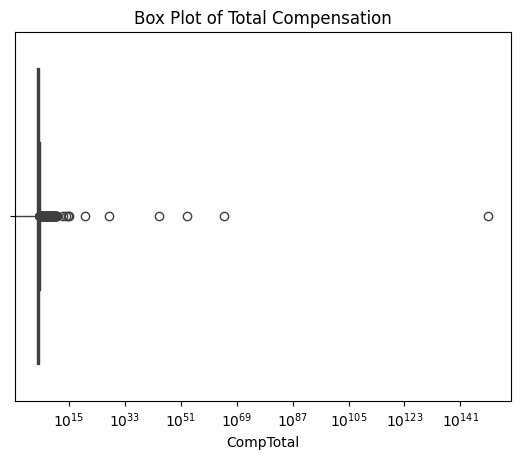

In [9]:
sns.boxplot(x=df_bx_plot)
plt.title('Box Plot of Total Compensation')
plt.xscale('log')

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [10]:
# your code goes here
df['Age'].unique()

array(['Under 18 years old', '35-44 years old', '45-54 years old',
       '18-24 years old', '25-34 years old', '55-64 years old',
       'Prefer not to say', '65 years or older'], dtype=object)

In [11]:
# Mid-point of each age range. 'Prefer not to say' becomes NaN automatically
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

df['Age_numeric'] = df['Age'].map(age_map)
df['Age_numeric'].unique()

array([16. , 39.5, 49.5, 21. , 29.5, 59.5,  nan, 70. ])

In [12]:
age_numeric = df['Age_numeric'].dropna()

Text(0.5, 1.0, 'Distribution of Respondents by Age (Numeric Approximation)')

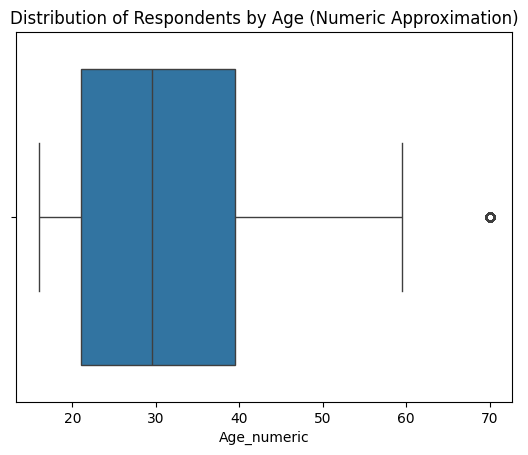

In [13]:
sns.boxplot(x=age_numeric)
plt.title('Distribution of Respondents by Age (Numeric Approximation)')

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [14]:
# your code goes here
df_box = df[['Age', 'CompTotal']].dropna()
df_box = df_box[df_box['Age'] != 'Prefer not to say']

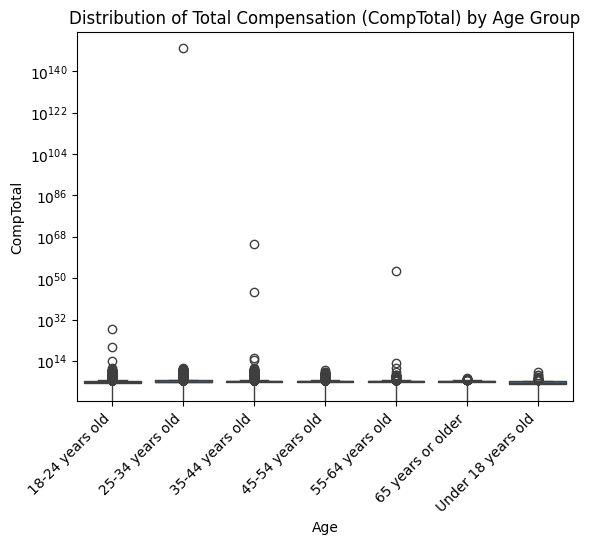

In [15]:
sns.boxplot(x='Age', y='CompTotal', data=df_box)
plt.title('Distribution of Total Compensation (CompTotal) by Age Group')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')

Age groups (18-24) and (35–44) exhibiting wider variability and more high-value outliers, indicating greater dispersion in earnings.

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [16]:
# your code goes here
df_comp_js6 = df[['CompTotal', 'JobSatPoints_6']].dropna()

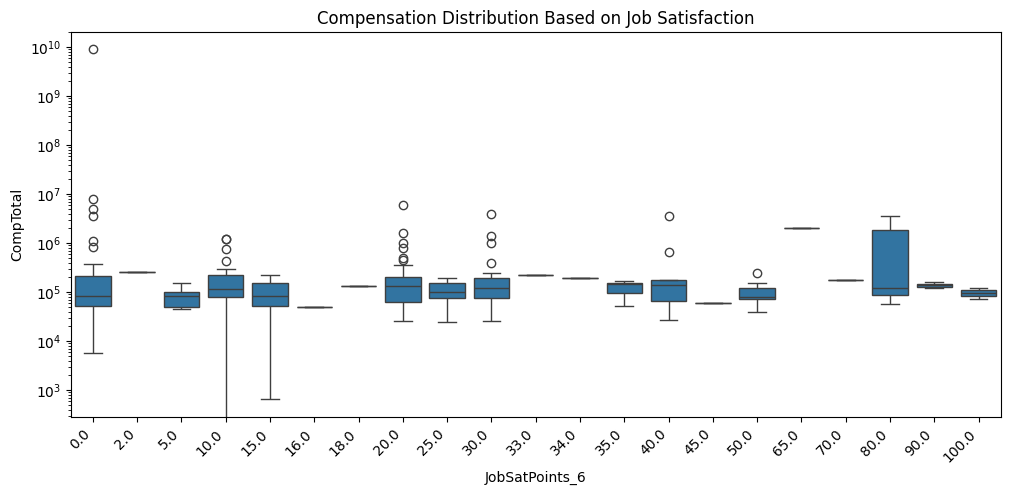

In [17]:
plt.figure(figsize=(12, 5))
sns.boxplot(
    x='JobSatPoints_6',
    y='CompTotal',
    data=df_comp_js6.head(200)
)

plt.title('Compensation Distribution Based on Job Satisfaction')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')

The box plot shows that compensation tends to increase with higher job satisfaction levels. Higher satisfaction categories exhibit higher medians and wider spreads, suggesting both higher typical earnings and greater variability among satisfied respondents.

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [18]:
# your code goes here
df['DevType'].unique()

array([None, 'Developer, full-stack', 'Developer Experience', 'Student',
       'Academic researcher', 'Project manager', 'Developer Advocate',
       'Developer, back-end', 'Other (please specify):',
       'Developer, front-end', 'Database administrator',
       'Developer, desktop or enterprise applications',
       'Cloud infrastructure engineer',
       'Data scientist or machine learning specialist',
       'Research & Development role',
       'Developer, embedded applications or devices',
       'System administrator', 'DevOps specialist', 'Engineering manager',
       'Designer', 'Security professional',
       'Senior Executive (C-Suite, VP, etc.)', 'Developer, mobile',
       'Developer, game or graphics', 'Data or business analyst',
       'Educator', 'Developer, QA or test', 'Product manager',
       'Developer, AI', 'Scientist', 'Engineer, site reliability',
       'Blockchain', 'Marketing or sales professional',
       'Hardware Engineer', 'Data engineer'], dtype=object)

In [24]:
df['ConvertedCompYearly'].unique()

array([    nan,   7322.,  30074., ...,  15637.,   9711., 116844.],
      shape=(6114,))

In [26]:
df_dev = df[['DevType', 'ConvertedCompYearly']].dropna()

In [27]:
df_dev = df_dev.assign(
    DevType=df_dev['DevType'].str.split(';')
).explode('DevType')
df_dev

,DevType,ConvertedCompYearly
72,Data scientist or machine learning specialist,7322.0
374,Academic researcher,30074.0
379,Data scientist or machine learning specialist,91295.0
385,"Developer, back-end",53703.0
389,Student,110000.0
...,...,...
41180,"Developer, embedded applications or devices",44640.0
41184,Project manager,170000.0
41185,"Developer, full-stack",116844.0
41186,"Developer, full-stack",12000.0


In [29]:
top5_devtypes = df_dev['DevType'].value_counts().head(5).index
top5_devtypes

Index(['Developer, full-stack', 'Developer, back-end', 'Developer, front-end',
       'Developer, desktop or enterprise applications', 'Developer, mobile'],
      dtype='object', name='DevType')

In [30]:
df_top5 = df_dev[df_dev['DevType'].isin(top5_devtypes)]
df_top5

,DevType,ConvertedCompYearly
385,"Developer, back-end",53703.0
398,"Developer, full-stack",195000.0
403,"Developer, full-stack",44586.0
414,"Developer, back-end",184712.0
415,"Developer, full-stack",79481.0
...,...,...
41175,"Developer, full-stack",15637.0
41178,"Developer, full-stack",9711.0
41179,"Developer, back-end",15600.0
41185,"Developer, full-stack",116844.0


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Developer, back-end'),
  Text(1, 0, 'Developer, full-stack'),
  Text(2, 0, 'Developer, front-end'),
  Text(3, 0, 'Developer, mobile'),
  Text(4, 0, 'Developer, desktop or enterprise applications')])

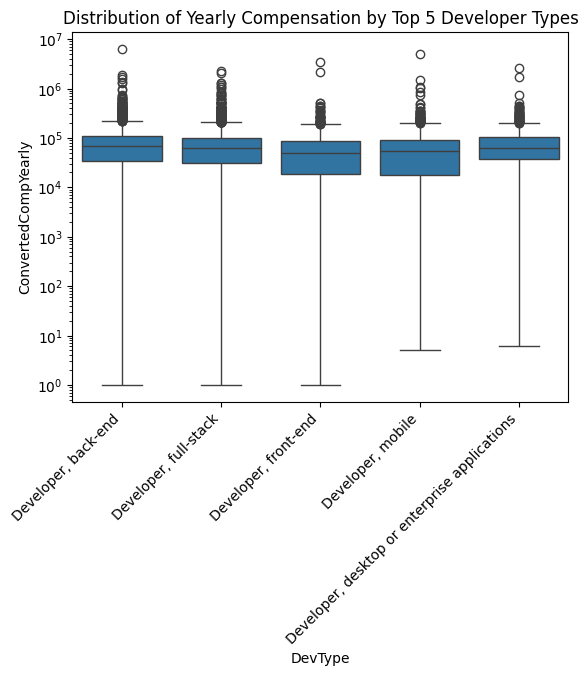

In [35]:
sns.boxplot(
    x='DevType',
    y='ConvertedCompYearly',
    data=df_top5
)

plt.yscale('log')  # crucial for salary data
plt.title('Distribution of Yearly Compensation by Top 5 Developer Types')
plt.xticks(rotation=45, ha='right')

The box plot reveals notable differences in yearly compensation across the top five developer roles. Some roles exhibit higher median compensation and greater variability, indicating stronger earning potential and a wider range of salaries. Other roles show more compact distributions, suggesting more standardized compensation levels.

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [37]:
# your code goes here
df_country = df[['Country', 'ConvertedCompYearly']].dropna()

In [41]:
top5_countries = df_country['Country'].value_counts().head(5).index
top5_countries

Index(['United States of America', 'Germany', 'Ukraine',
       'United Kingdom of Great Britain and Northern Ireland', 'India'],
      dtype='object', name='Country')

In [43]:
df_top5_countries = df_country[df_country['Country'].isin(top5_countries)]

([0, 1, 2, 3, 4],
 [Text(0, 0, 'United States of America'),
  Text(1, 0, 'United Kingdom of Great Britain and Northern Ireland'),
  Text(2, 0, 'Germany'),
  Text(3, 0, 'Ukraine'),
  Text(4, 0, 'India')])

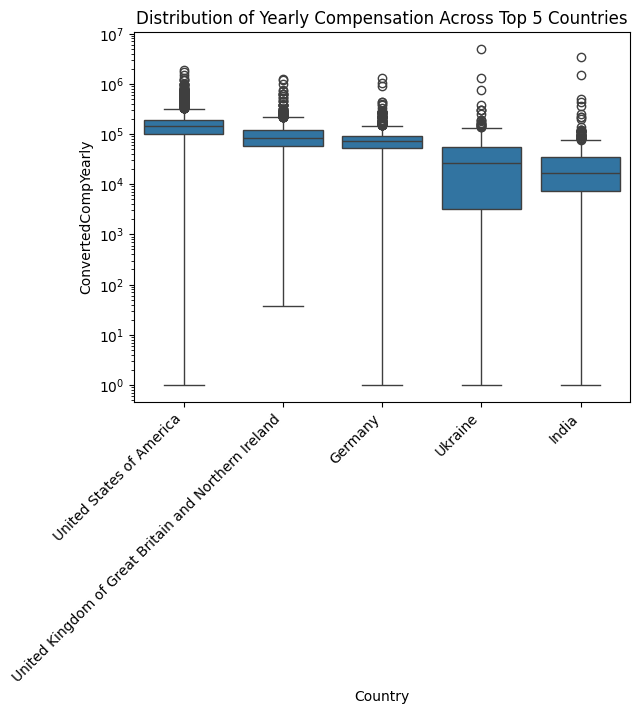

In [45]:
sns.boxplot(
    x='Country',
    y='ConvertedCompYearly',
    data=df_top5_countries
)

plt.yscale('log')
plt.title('Distribution of Yearly Compensation Across Top 5 Countries')
plt.xticks(rotation=45, ha='right')

The box plot indicates substantial variation in yearly compensation across the top five respondent countries. Median compensation is higher in the United States of America and comparatively lower for India. The presence of outliers across all countries highlights a small group of high earners in each region.

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [50]:
# your code goes here
df['Employment'].unique()

array(['Employed, full-time', 'Student, full-time',
       'Student, full-time;Not employed, but looking for work',
       'Independent contractor, freelancer, or self-employed',
       'Not employed, and not looking for work',
       'Employed, full-time;Student, part-time',
       'Employed, full-time;Independent contractor, freelancer, or self-employed',
       'Employed, full-time;Student, full-time', 'Employed, part-time',
       'Student, full-time;Employed, part-time',
       'Student, part-time;Employed, part-time', 'I prefer not to say',
       'Not employed, but looking for work', 'Student, part-time',
       'Employed, full-time;Student, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time',
       'Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time',
       'Independent contractor, freelancer, or self-employed;Employed, part-time',
       'Independent contractor, freelancer, or self-employed;Student, par

In [51]:
df_emp = df[['Employment', 'ConvertedCompYearly']].dropna()

In [52]:
df_emp['EmploymentType'] = df_emp['Employment'].str.split(';').str[0]

In [53]:
top_emp_types = df_emp['EmploymentType'].value_counts().head(5).index
df_emp_top = df_emp[df_emp['EmploymentType'].isin(top_emp_types)]

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Employed, full-time'),
  Text(1, 0, 'Independent contractor, freelancer, or self-employed'),
  Text(2, 0, 'Student, part-time'),
  Text(3, 0, 'Student, full-time'),
  Text(4, 0, 'Employed, part-time')])

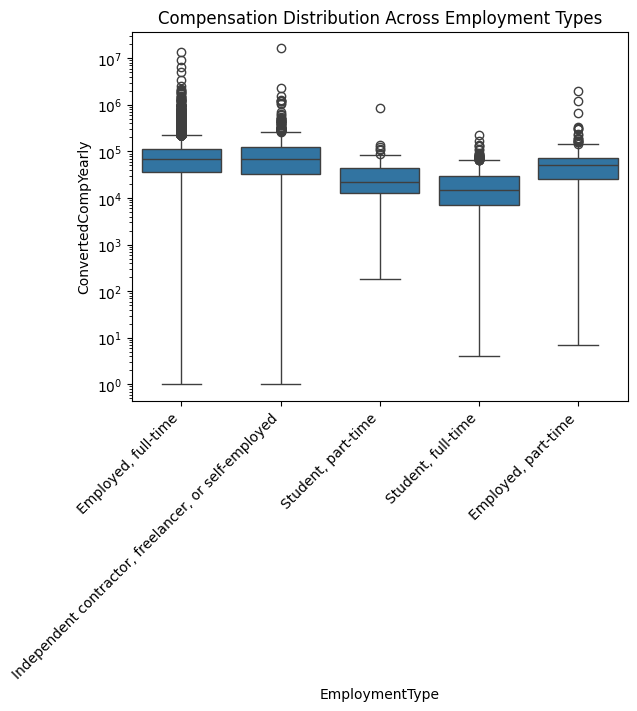

In [55]:
sns.boxplot(
    x='EmploymentType',
    y='ConvertedCompYearly',
    data=df_emp_top
)

plt.yscale('log')
plt.title('Compensation Distribution Across Employment Types')
plt.xticks(rotation=45, ha='right')

The analysis reveals clear compensation differences across employment types. Full-time employed respondents show higher median compensation compared to part-time workers and students. Independent contractors exhibit wider compensation ranges and more outliers, indicating income variability. The log-scaled box plot highlights both inequality and earning potential differences among employment categories.

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [65]:
# your code goes here
df_js6 = df[['YearsCodePro', 'JobSatPoints_6']].dropna()

In [ ]:
df_js6.groupby('JobSatPoints_6')['YearsCodePro'].median()

In [68]:
df_js6['YearsCodePro'] = (
    df_js6['YearsCodePro']
    .replace({
        'Less than 1 year': 0.5,
        'More than 50 years': 51
    })
    .astype(float)
)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, '0.0'),
  Text(1, 0, '5.0'),
  Text(2, 0, '8.0'),
  Text(3, 0, '10.0'),
  Text(4, 0, '15.0'),
  Text(5, 0, '20.0'),
  Text(6, 0, '25.0'),
  Text(7, 0, '30.0'),
  Text(8, 0, '33.0'),
  Text(9, 0, '35.0'),
  Text(10, 0, '40.0'),
  Text(11, 0, '50.0'),
  Text(12, 0, '60.0'),
  Text(13, 0, '65.0'),
  Text(14, 0, '75.0'),
  Text(15, 0, '80.0'),
  Text(16, 0, '90.0'),
  Text(17, 0, '100.0')])

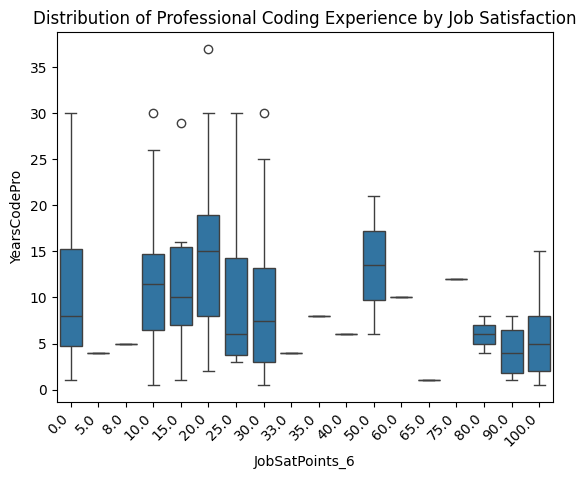

In [69]:
sns.boxplot(
    x='JobSatPoints_6',
    y='YearsCodePro',
    data=df_js6.head(100)
)

plt.title('Distribution of Professional Coding Experience by Job Satisfaction')
plt.xticks(rotation=45, ha='right')

The distribution of professional coding experience varies across job satisfaction levels. Higher satisfaction scores tend to correspond with greater median years of professional experience, suggesting that experience may contribute to job fulfillment. However, the presence of outliers at most satisfaction levels indicates that both early-career and highly experienced developers can report similar satisfaction levels.

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [70]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
